In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

c:\Users\Rehab.Kambal\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!pip install noisereduce


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import noisereduce as nr
import os
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
import re
import glob
import pandas as pd

In [5]:
RAVDESS_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
TESS_PATH    = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess"
SAVEE_PATH   = "/kaggle/input/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee"
CREMA_PATH   = "/kaggle/input/datasets/ejlok1/cremad"

In [6]:
RAVDESS_MAP = {
    "01": "neutral", "02": "neutral", "03": "happy", "04": "sad",
    "05": "angry", "06": "fear", "07": "disgust", "08": "surprise",
}

SAVEE_MAP = {
    "a": "angry", "d": "disgust", "f": "fear", "h": "happy",
    "n": "neutral", "sa": "sad", "su": "surprise",
}

CREMA_MAP = {
    "ANG": "angry", "DIS": "disgust", "FEA": "fear",
    "HAP": "happy", "NEU": "neutral", "SAD": "sad",
}

TESS_MAP = {
    "angry": "angry",
    "disgust": "disgust",
    "fear": "fear",
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad",
    "ps": "surprise",
}

In [7]:
def _wavs(root):
    return glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)

# RAVDESS
def parse_ravdess(root):
    for f in _wavs(root):
        try:
            code = os.path.basename(f).split("-")[2]
            yield f, RAVDESS_MAP.get(code), "RAVDESS"
        except:
            continue

In [8]:
# Tess
def parse_tess(root):
    for f in _wavs(root):
        token = os.path.splitext(os.path.basename(f))[0].split("_")[-1].lower()
        yield f, TESS_MAP.get(token), "TESS"

In [9]:
# SAVEE
def parse_savee(root):
    for f in _wavs(root):
        name = os.path.splitext(os.path.basename(f))[0]

        # مثال: DC_a01 -> a
        token = name.split("_")[-1]
        token = re.sub(r"\d+", "", token)

        yield f, SAVEE_MAP.get(token), "SAVEE"

In [10]:
# CREMA-D
def parse_crema(root):
    for f in _wavs(root):
        parts = os.path.basename(f).split("_")
        if len(parts) < 3:
            continue
        code = parts[2]
        yield f, CREMA_MAP.get(code), "CREMA-D"

In [11]:
def build_metadata():
    rows = []

    for parser, root in [
        (parse_ravdess, RAVDESS_PATH),
        (parse_tess, TESS_PATH),
        (parse_savee, SAVEE_PATH),
        (parse_crema, CREMA_PATH),
    ]:
        data = list(parser(root))
        print(parser.__name__, len(data))
        rows.extend(data)

    print("Total before DataFrame:", len(rows))

    df = pd.DataFrame(rows, columns=["path", "emotion", "source"])

    print("After DataFrame:", df.shape)

    print("Missing emotion:", df["emotion"].isna().sum())

    df = df.dropna(subset=["emotion"])

    print("After dropna:", df.shape)

    missing_files = (~df["path"].apply(os.path.exists)).sum()
    print("Files not found:", missing_files)

    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)

    print("Final:", df.shape)

    return df

In [15]:
df = build_metadata()

print(df.shape)
# print(df["source"].value_counts())
# print(df["emotion"].value_counts())
df.head()

parse_ravdess 0
parse_tess 0
parse_savee 0
parse_crema 0
Total before DataFrame: 0
After DataFrame: (0, 3)
Missing emotion: 0
After dropna: (0, 3)
Files not found: 0
Final: (0, 0)
(0, 0)


""


In [ ]:
df.to_csv("ser_metadata.csv", index=False)
print("total files:", len(df))
print("\nper source / emotion:")
print(df.groupby(["source", "emotion"]).size().unstack(fill_value=0))
print("\nclass totals:")
print(df["emotion"].value_counts())

total files: 16402

per source / emotion:
emotion  angry  disgust  fear  happy  neutral   sad  surprise
source                                                       
CREMA-D   1271     1271  1271   1271     1087  1271         0
RAVDESS    384      384   384    384      576   384       384
SAVEE       60       60    60     60      120    60        60
TESS       800      800   800    800      800   800       800

class totals:
emotion
neutral     2583
disgust     2515
fear        2515
happy       2515
sad         2515
angry       2515
surprise    1244
Name: count, dtype: int64


In [14]:
import IPython.display as ipd

In [15]:
ipd.Audio(df.loc[0, "path"])

In [16]:
ipd.Audio(df.loc[3, "path"])

In [17]:
ipd.Audio(df["path"].iloc[3])

In [18]:
audio_file = df["path"].tolist()
emotion = df["emotion"].tolist()

In [19]:
print(emotion[3])
ipd.Audio(audio_file[3])

disgust


In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16402 entries, 0 to 16401
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   path     16402 non-null  object
 1   emotion  16402 non-null  object
 2   source   16402 non-null  object
dtypes: object(3)
memory usage: 384.6+ KB


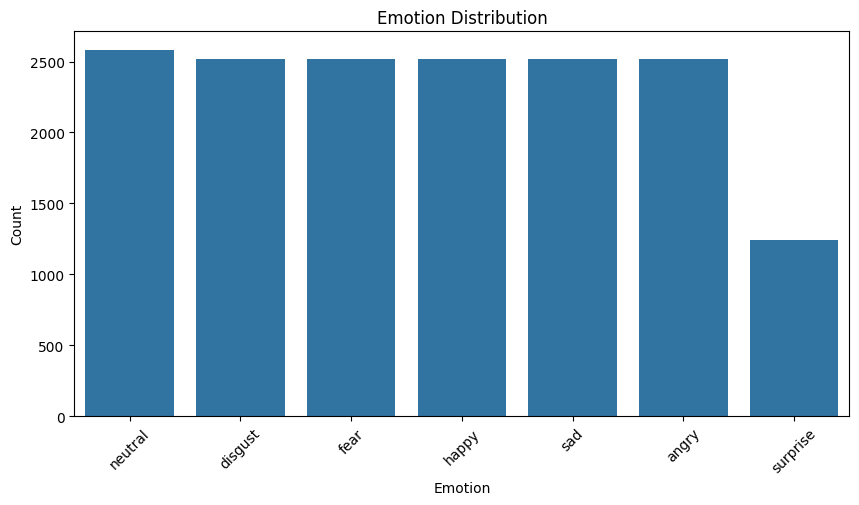

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

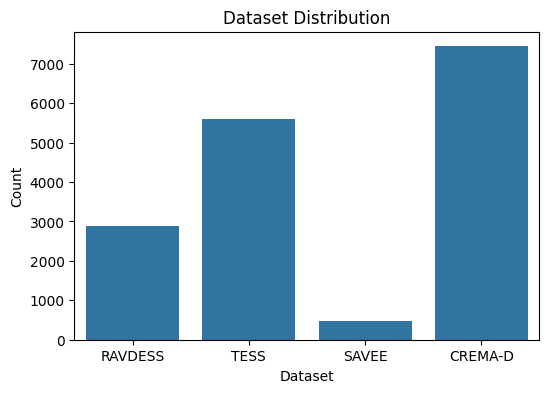

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='source')

plt.title("Dataset Distribution")
plt.xlabel("Dataset")
plt.ylabel("Count")

plt.show()

In [23]:
y, sr = librosa.load(df.loc[3, "path"], sr=None)

print(f"y: {y[:10]}")
print(f"Shape of y: {y.shape}")
print(f"Sample Rate: {sr}")

y: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Shape of y: (174575,)
Sample Rate: 48000


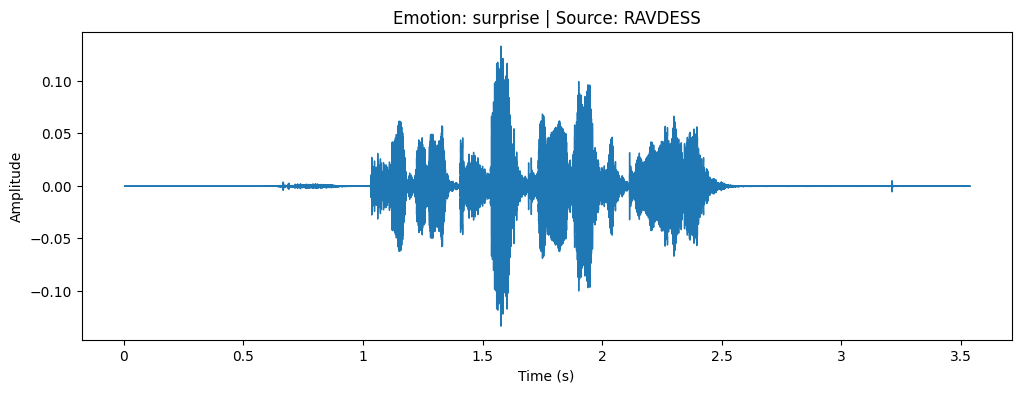

In [24]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

file_path = df.loc[0, "path"]

y, sr = librosa.load(file_path, sr=None)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)

plt.title(f"Emotion: {df.loc[0, 'emotion']} | Source: {df.loc[0, 'source']}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

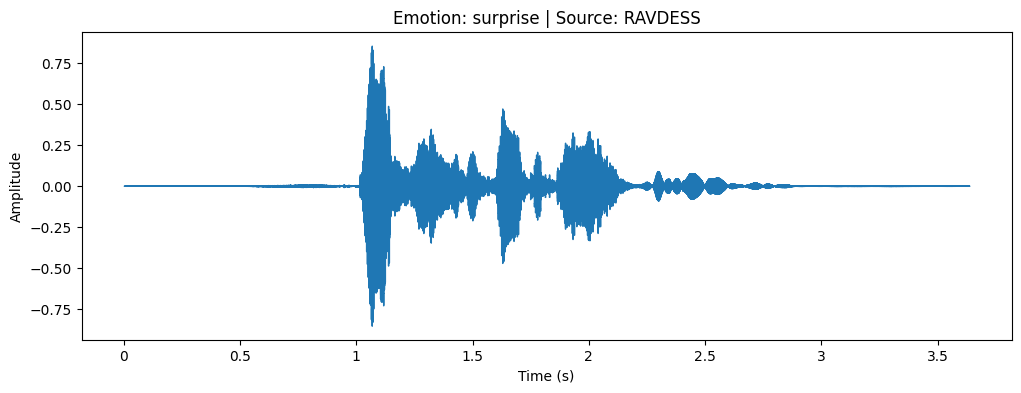

In [25]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

file_path = df.loc[100, "path"]

y, sr = librosa.load(file_path, sr=None)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)

plt.title(f"Emotion: {df.loc[0, 'emotion']} | Source: {df.loc[0, 'source']}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

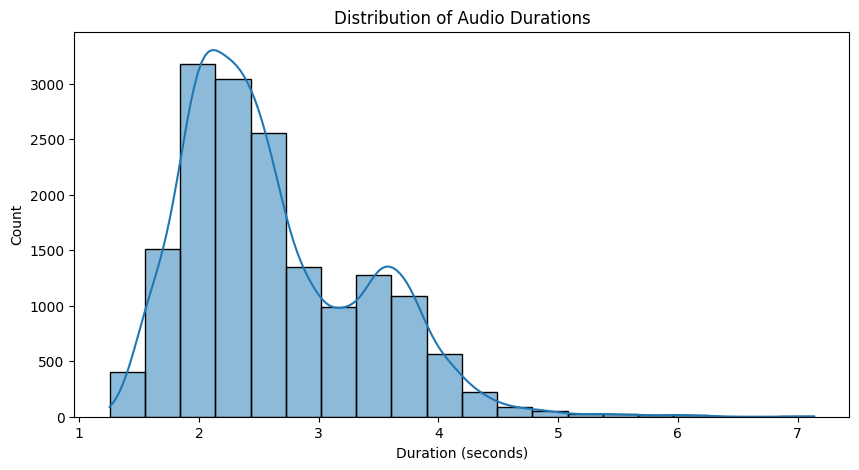

In [26]:
import librosa
import seaborn as sns
import matplotlib.pyplot as plt

durations = []

for path in df["path"]:
    y, sr = librosa.load(path, sr=None)
    durations.append(librosa.get_duration(y=y, sr=sr))

df["duration"] = durations

plt.figure(figsize=(10,5))
sns.histplot(durations, bins=20, kde=True)

plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")

plt.show()

In [27]:
df["duration"].describe()

count    16402.000000
mean         2.617590
std          0.751894
min          1.254076
25%          2.064963
50%          2.435750
75%          3.103125
max          7.138730
Name: duration, dtype: float64

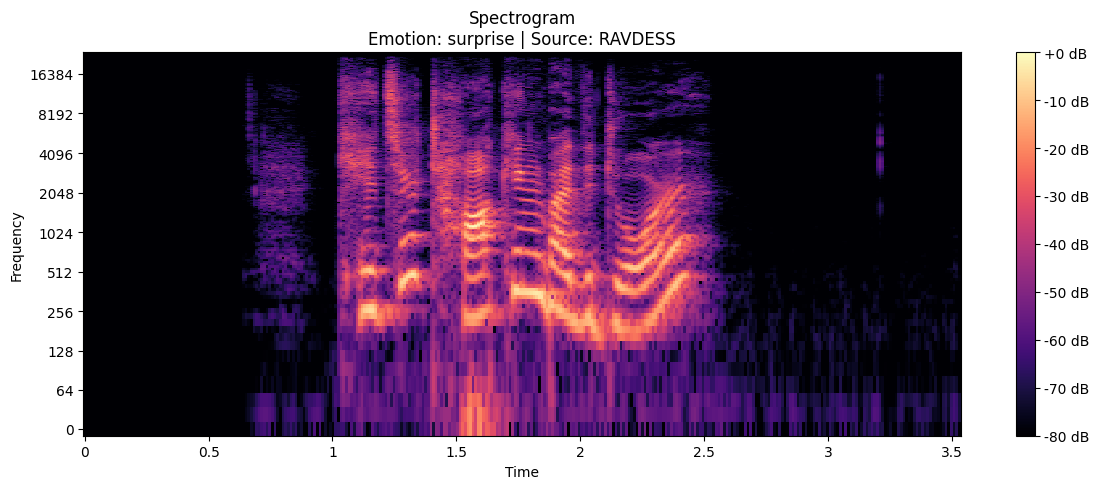

In [28]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

file_path = df.loc[0, "path"]

y, sr = librosa.load(file_path, sr=None)

# STFT
D = librosa.stft(y)

# Convert to dB
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis="time",
    y_axis="log",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram\nEmotion: {df.loc[0,'emotion']} | Source: {df.loc[0,'source']}")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [29]:
duration = librosa.get_duration(y=y, sr=sr)

print(f"Total samples: {len(y)}")
print(f"Duration: {duration:.2f} seconds")
print(f"Sample Rate: {sr} Hz")

Total samples: 169769
Duration: 3.54 seconds
Sample Rate: 48000 Hz


(128, 332)


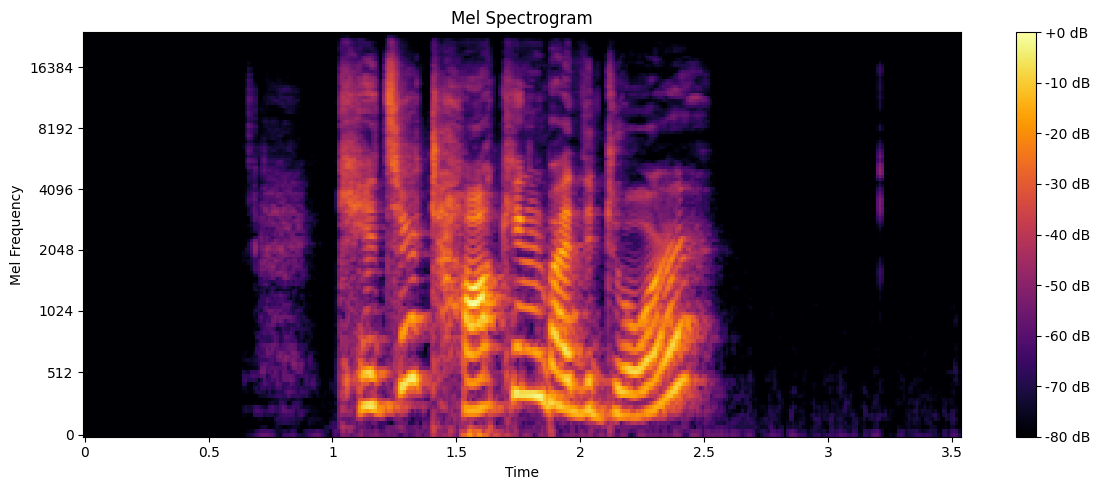

In [30]:
import librosa.display

mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

print(mel_db.shape)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    fmax=sr//2,
    cmap="inferno"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

In [31]:
import noisereduce as nr
import librosa
import IPython.display as ipd

file_path = df.loc[0, "path"]

y, sr = librosa.load(file_path, sr=None)

reduced_noise = nr.reduce_noise(y=y, sr=sr)

print("Original:", len(y))
print("Denoised:", len(reduced_noise))

ipd.Audio(reduced_noise, rate=sr)

Original: 169769
Denoised: 169769


In [32]:
def preprocess_audio(path):
    y, sr = librosa.load(path, sr=22050, mono=True)

    y = nr.reduce_noise(y=y, sr=sr)
    y = librosa.util.normalize(y)
    y, _ = librosa.effects.trim(y)

    return y, sr

In [33]:
import librosa
import numpy as np
import noisereduce as nr

def preprocess_audio(path):
    y, sr = librosa.load(path, sr=22050, mono=True)

    y = nr.reduce_noise(y=y, sr=sr)

    # 2. Normalize
    y = librosa.util.normalize(y)

    # 3. Remove silence
    intervals = librosa.effects.split(y, top_db=20)
    if len(intervals) > 0:
        y = np.concatenate([y[start:end] for start, end in intervals])

    return y, sr

In [34]:
def preprocess_audio(path):
    y, sr = librosa.load(path, sr=22050, mono=True)

    # optional noise reduction
    y = nr.reduce_noise(y=y, sr=sr)

    # trim silence
    intervals = librosa.effects.split(y, top_db=20)
    if len(intervals) > 0:
        y = np.concatenate([y[s:e] for s, e in intervals])

    # normalization
    max_val = np.max(np.abs(y))
    if max_val != 0:
        y = y / max_val

    return y, sr

In [35]:
df_small = df.sample(2000, random_state=42)

In [36]:
features = []
labels = []

for i, path in enumerate(df["path"]):

    # load audio
    y, sr = librosa.load(path, sr=22050, mono=True)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    # Spectral Centroid
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spec_centroid_mean = np.mean(spec_centroid)

    # Spectral Rolloff
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    spec_rolloff_mean = np.mean(spec_rolloff)   # ✔ FIXED

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)

    # RMS
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)

    # feature vector
    feature_vector = np.hstack([
        mfcc_mean,
        spec_centroid_mean,
        spec_rolloff_mean,
        zcr_mean,
        rms_mean
    ])

    features.append(feature_vector)

    # ✔ correct label (emotion)
    labels.append(df.loc[i, "emotion"])

print(len(features))
print(len(labels))

16402
16402


In [37]:
print(len(features))
print(len(features[0]))
print(features[0])

16402
17
[-5.78057007e+02  3.84509087e+01 -1.45256233e+01  1.00585623e+01
 -7.26893139e+00 -7.33844042e+00 -3.07434559e+00 -5.95407295e+00
 -3.08556080e+00 -3.63332868e+00 -4.09126902e+00 -4.76727247e+00
 -3.25836658e+00  2.69088151e+03  5.05270278e+03  2.35686657e-01
  6.98133558e-03]


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB


In [39]:
# Convert

X = np.array(features)
y = np.array(labels)

In [40]:
# Split FIRST (very important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=45, stratify=y
)

In [41]:
# Scaling AFTER split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [42]:
# Model
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [43]:
print(model.score(X_train,y_train))
model.score(X_test,y_test)

0.30035820440515204


0.30996647363608654

In [44]:
y_pred = model.predict(X_test)


In [45]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

       angry       0.54      0.41      0.47       503
     disgust       0.25      0.30      0.27       503
        fear       0.30      0.04      0.08       503
       happy       0.30      0.10      0.15       503
     neutral       0.45      0.27      0.34       517
         sad       0.34      0.51      0.41       503
    surprise       0.19      0.77      0.31       249

    accuracy                           0.31      3281
   macro avg       0.34      0.34      0.29      3281
weighted avg       0.35      0.31      0.29      3281



In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [47]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [48]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    results.append((name, acc, f1))
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("-"*40)


Logistic Regression
Accuracy: 0.47363608655897593
F1-score: 0.46952706374648573
----------------------------------------

SVM (RBF)
Accuracy: 0.6494971045412984
F1-score: 0.6470890810343095
----------------------------------------

Random Forest
Accuracy: 0.7083206339530631
F1-score: 0.7053686868060531
----------------------------------------

KNN
Accuracy: 0.632429137458092
F1-score: 0.6305260329392124
----------------------------------------


In [49]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score"])

results_df = results_df.sort_values(by="F1-score", ascending=False)

print(results_df)

                 Model  Accuracy  F1-score
2        Random Forest  0.708321  0.705369
1            SVM (RBF)  0.649497  0.647089
3                  KNN  0.632429  0.630526
0  Logistic Regression  0.473636  0.469527


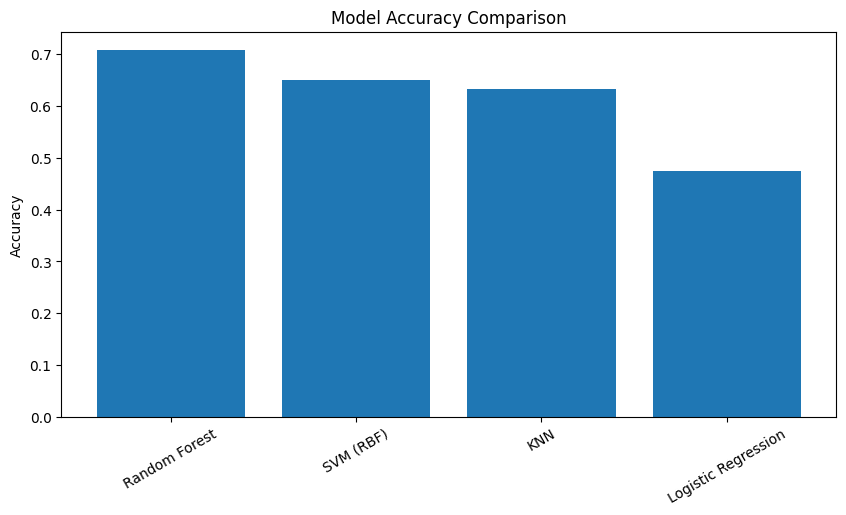

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")

plt.show()

In [51]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Random Forest


In [52]:
best_model = RandomForestClassifier(n_estimators=100, random_state=42)

best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [53]:
y_pred = best_model.predict(X_test)

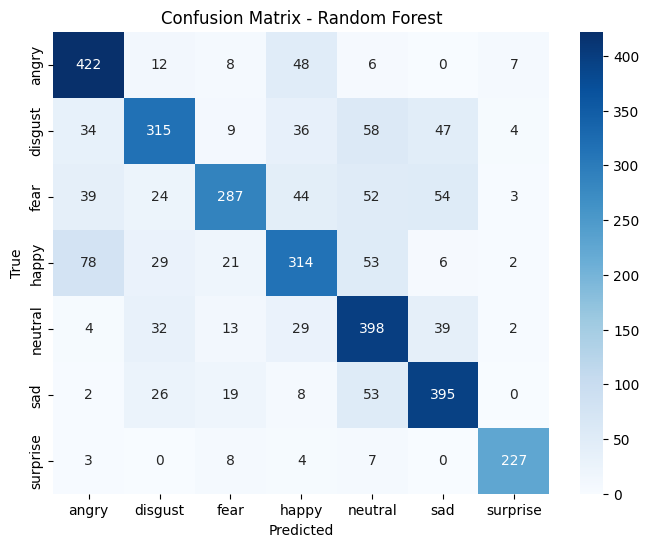

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [55]:
def predict_emotion(file_path):
    y, sr = preprocess_audio(file_path)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rms = np.mean(librosa.feature.rms(y=y))

    feature_vector = np.hstack([
        mfcc_mean,
        spec_centroid,
        spec_rolloff,
        zcr,
        rms
    ])

    feature_vector = scaler.transform([feature_vector])

    return best_model.predict(feature_vector)[0]

In [56]:
import pandas as pd
import pickle

# results table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score"])
results_df = results_df.sort_values(by="F1-score", ascending=False)

# best model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# save everything
pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [57]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))